# Классификация животных на изображениях


Базовый вариант решения третьего домашнего задания: задача многоклассовой классификации изображений

Учебный курс "[Программирование глубоких нейронных сетей на Python](https://openedu.ru/course/urfu/PYDNN/)".

<a target="_blank" href="https://colab.research.google.com/github/sozykin/dlpython_course/blob/master/04_transfer_learning/pytorch/animals.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



# Импорт библиотек


In [78]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
import pandas as pd

from torchvision.transforms import ToTensor, ToPILImage, Normalize, Compose
from torch.utils.data import DataLoader
import numpy as np
import random

import io
import os
from tqdm import tqdm

from PIL import Image
%matplotlib inline

# Загрузка данных

In [2]:
# !wget https://www.dropbox.com/scl/fi/ujneuteydjf2rekrcrsrv/train.zip?rlkey=eisyrf0d7pqchalienoag4iut&dl=1

In [79]:
# !wget https://www.dropbox.com/scl/fi/z6tfzjblwok0n58l7xta1/test.zip?rlkey=ssrwcvdank0h17ce8fvobqofg&dl=1

In [80]:
#↓ "распакуй" + имя архива
# !unzip train.zip
# !unzip test.zip

Загрузим текстовые файлы в которых перечислены названия файлов и метки классов (для тренировочной выборки)

In [81]:
# !wget https://raw.githubusercontent.com/dayekb/mpti_ml/main/competition2/train.csv

In [82]:
train = pd.read_csv('train.csv', sep=',', index_col=0)
train

,label
id,
abdu-rahman-2934-unsplash.jpg,0
anete-lusina-609858-unsplash.jpg,0
anselmo-stevin-laksito-387930-unsplash.jpg,0
cat-mapper-max-ogden-204436-unsplash.jpg,0
cel-lisboa-73965-unsplash.jpg,0
...,...
OIP-Wu_4fQ30ezKIJMuFs6KuvAHaEM.jpeg,7
OIP-wu_w7ncADQ9Vh5QqcCCXbgHaE8.jpeg,8
OIP--wuFK6RSOflCu9IAOxIyugHaE8.jpeg,8


В файле submission представлены названия файлов для тестовой выборки. метки классов заполнены нулями

In [83]:
# !wget https://raw.githubusercontent.com/dayekb/mpti_ml/main/competition2/submission.csv

In [84]:
submission = pd.read_csv('submission.csv', sep=',', index_col=0)
submission

,label
id,
ee32b90c29f11c22d2524518b7444f92e37fe5d404b0144390f8c079a4e5b6_640.jpg,0
ee33b00e2ee90021d85a5854ee454296eb70e3c818b413449df1c17fa2ee_640.jpg,0
ee37b70620fd1c22d2524518b7444f92e37fe5d404b0144390f8c079a2efb1_640.jpg,0
ee3cb70b2bf31c22d2524518b7444f92e37fe5d404b0144390f8c079a2efb1_640.jpg,0
ef31b80e2ef01c22d2524518b7444f92e37fe5d404b0144390f8c079a4e5b6_640.jpg,0
...,...
q-aila-162475-unsplash.jpg,0
sam-burriss-378658-unsplash.jpg,0
sarah-dorweiler-128578-unsplash.jpg,0


Определяем инструмент предварительной обработки изображений из набора данных

Добавляется строка

`transforms.Lambda(lambda x: x[:3])`

которая нужна для того чтобы трансформировать некоторые 4-х канальные изображения из выборки в 3-х канальные

In [85]:
my_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x[:3]),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

Создадим свой класс для загрузки данных из папки

Наследуем от `Dataset`

Особенности написанного класса

* считываются все изображения в папке `img_dir` по индексам, обозначенным в файле `txt_path` (`samples`)
* из файла `txt_path` также берутся метки классов (`target`)

In [86]:
class CustomDataSet(Dataset):
    def __init__(self, txt_path='/content/train.csv', img_dir='/content/train',
                 transform=None, test=False):
        df = pd.read_csv(txt_path, sep=',', index_col=0)
        self.img_names = df.index.values
        self.df = df
        self.txt_path = txt_path
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_names)

    def get_image_from_folder(self, name):

        image = Image.open(os.path.join(self.img_dir, name))
        return image

    def __getitem__(self, idx):
        sample = self.get_image_from_folder(self.img_names[idx])
        if self.transform is not None:
            sample = self.transform(sample)
        target = self.df.label[idx]
        return sample, target

Выполним загрузку данных в два этапа



1. Создадим экземпляр класса `CustomDataSet`, указав
* путь к файлу с целевыми метками и названием тренировочных файлов
* путь к папке с тренировочными данными
* инструмент предварительной обработки

In [87]:
train_dataset = CustomDataSet(txt_path='train.csv',
                             img_dir='train',
                             transform=my_transforms)

2. Создадим загрузчик данных, используя созданный ранее экземпляр класса `CustomDataSet`

In [88]:
batch_size = 64

train_loader = DataLoader(dataset=train_dataset,
                          batch_size=batch_size,
                          shuffle=True,
                          num_workers=2,
                          )

Имена классов

In [89]:
classes = ['кошка', 'слон', 'бабочка', 'овца',
           'паук', 'лошадь', 'собака', 'корова',
           'курица', 'белка']

Просматриваем примеры изображений

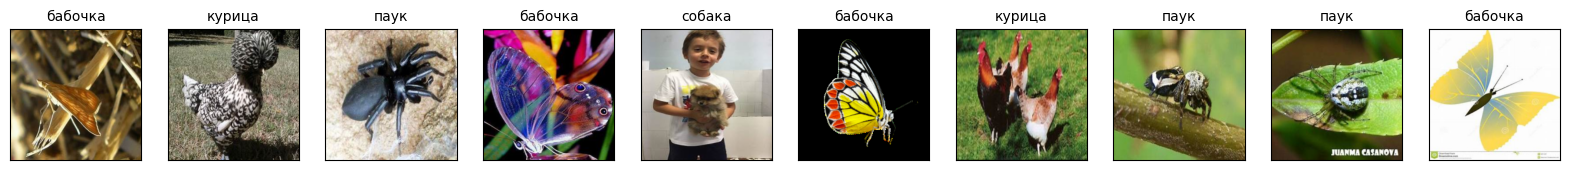

In [90]:
nsamples=10

imgs, label = next(iter(train_loader))

fig=plt.figure(figsize=(20,10),facecolor='w')
for i in range(nsamples):
    ax = plt.subplot(1,nsamples, i+1)
    img = imgs[i] / 2 + 0.5     # обратная нормализация
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.set_title(classes[label[i]], fontsize=10)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

## Создаем модель




In [91]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

In [92]:
device

'cuda'

Загружаем предварительно обученную модель

In [93]:
resnet = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)

Добавляем новый классификатор нашего набора данных

In [94]:
resnet.fc = nn.Sequential(
                         nn.Linear(resnet.fc.in_features, 32),
                         nn.ReLU(),
                         nn.Linear(32, 10))

Передаем модель на устройство

In [95]:
model = resnet.to(device)
# print(model)

## Обучаем модель

Задаем функцию ошибки - категориальная перекрестная энтропия



In [96]:
loss_fn = nn.CrossEntropyLoss()

Задаем оптимизатор

In [97]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Определяем функцию для обучения нейронной сети



In [98]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Включаем режим обучения
    model.train()
    # В цикле получаем все мини-выборки
    # X - изображение
    # y - номер класса
    correct = 0
    for batch, (X, y) in enumerate(dataloader):
        # Передаем данные на устройство
        X, y = X.to(device), y.to(device)
        # Обнуляем значения градиента
        optimizer.zero_grad()

        # Расчитываем данные на выходе из нейронной сети
        pred = model(X)

        # Расчитываем значение ошибки
        loss = loss_fn(pred, y)

        # Обратное распространение ошиби
        loss.backward()

        # Выполняем шаг обучения (изменение весов)
        optimizer.step()

        # Подсчитываем количество правильных ответов
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        # Печатаем прогресс каждые 50 мини-выборок
        if batch % 50 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"Ошибка: {loss:>7f}  [{current:>5d}/{size:>5d}]")

    # Точность на обучающем наборе данных
    correct /= size
    print(f"Точность на обучающем наборе данных: {100*correct:>0.1f}%")


Обучаем модель в течение 2 эпох



In [99]:
epochs = 3
for t in range(epochs):
    print(f"Эпоха {t+1}\n-------------------------------")
    # Обучение модели
    train(train_loader, model, loss_fn, optimizer)
print("Обучение завершено!")

Эпоха 1
-------------------------------
Ошибка: 2.326871  [   64/21949]
Ошибка: 0.899004  [ 3264/21949]
Ошибка: 0.546562  [ 6464/21949]
Ошибка: 0.540887  [ 9664/21949]
Ошибка: 0.598224  [12864/21949]
Ошибка: 0.561334  [16064/21949]
Ошибка: 0.329575  [19264/21949]
Точность на обучающем наборе данных: 83.0%
Эпоха 2
-------------------------------
Ошибка: 0.181747  [   64/21949]
Ошибка: 0.250302  [ 3264/21949]
Ошибка: 0.298151  [ 6464/21949]
Ошибка: 0.474329  [ 9664/21949]
Ошибка: 0.257963  [12864/21949]
Ошибка: 0.357943  [16064/21949]
Ошибка: 0.276752  [19264/21949]
Точность на обучающем наборе данных: 90.5%
Эпоха 3
-------------------------------
Ошибка: 0.137286  [   64/21949]
Ошибка: 0.102740  [ 3264/21949]
Ошибка: 0.139893  [ 6464/21949]
Ошибка: 0.160359  [ 9664/21949]
Ошибка: 0.231142  [12864/21949]
Ошибка: 0.277476  [16064/21949]
Ошибка: 0.175781  [19264/21949]
Точность на обучающем наборе данных: 93.4%
Эпоха 4
-------------------------------
Ошибка: 0.301071  [   64/21949]
Ошибка:

KeyboardInterrupt: 

## Матрица ошибок на обучающей выборке


100%|██████████████████████████████████████████████████████████████████| 343/343 [00:31<00:00, 10.76it/s]


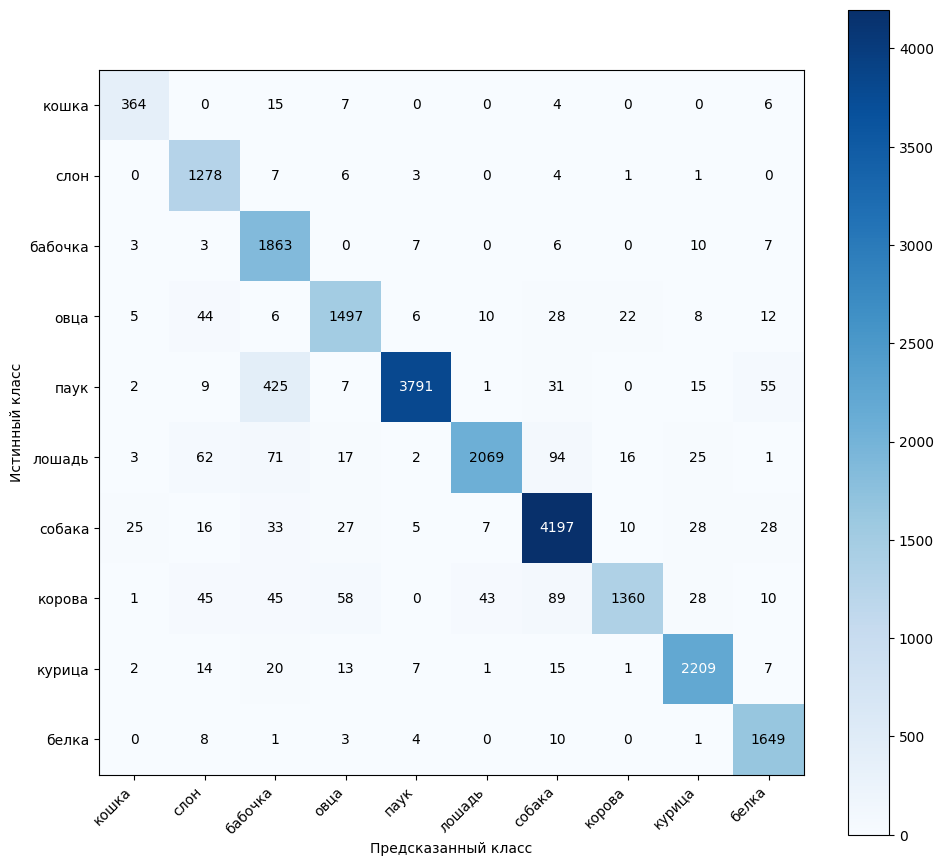

In [100]:
from sklearn.metrics import confusion_matrix

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for X, y in tqdm(train_loader):
        X = X.to(device)
        preds = model(X).argmax(dim=1).cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(y.numpy().tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(classes)), classes, rotation=45, ha='right')
ax.set_yticks(range(len(classes)), classes)
ax.set_xlabel('Предсказанный класс')
ax.set_ylabel('Истинный класс')

thresh = cm.max() / 2
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')

fig.colorbar(im)
plt.tight_layout()
plt.show()

## Распознавание изображений из тестового набора данных



Включаем режим оценки качества модели

In [101]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Создадим загрузчик для тестовых данных, на которых вам надо будет сделать предсказание

In [102]:
test_dataset = CustomDataSet(txt_path='submission.csv',
                             img_dir='test',
                             transform=my_transforms)


Важно - данные в этом случае не надо перемешивать, поскольку при загрузке файла с ответом необходим строгий порядок

In [103]:
test_loader = DataLoader(dataset=test_dataset,
                          batch_size=64,
                          shuffle=False
                          )

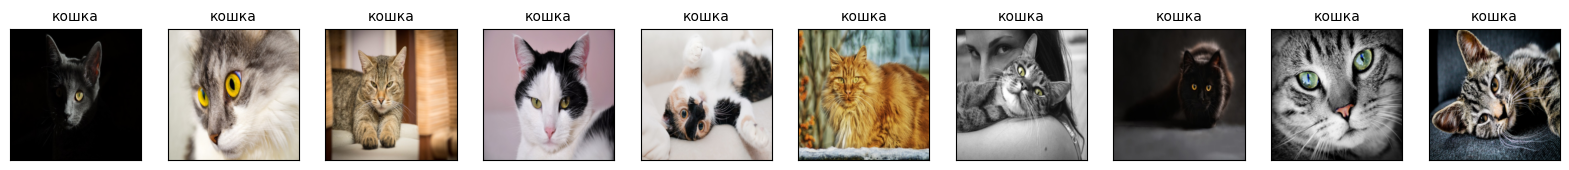

In [104]:


nsamples=10

imgs, label = next(iter(test_loader))

fig=plt.figure(figsize=(20,10),facecolor='w')
for i in range(nsamples):
    ax = plt.subplot(1,nsamples, i+1)
    img = imgs[i] / 2 + 0.5     # обратная нормализация
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.set_title(classes[label[i]], fontsize=10)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

Реализуем предсказание модели на тестовых данных

In [108]:
test_predictions = []

for inputs, _ in tqdm(test_loader):
    inputs = inputs.to(device)
    with torch.set_grad_enabled(False):
        preds = model(inputs)
    test_predictions.append(preds.argmax(dim = 1).data.cpu().numpy())

test_predictions = np.concatenate(test_predictions)


100%|████████████████████████████████████████████████████████████████████| 39/39 [00:11<00:00,  3.38it/s]


Откроем файл для загрузки (предсказания заполнены нулями)

In [109]:
test_predictions[:100]

array([0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 4, 1, 2, 0, 0, 0,
       2, 9, 0, 0, 0, 6, 0, 0, 9, 0, 5, 0, 2, 0, 1, 1, 1, 1, 9, 1, 1, 1,
       1, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 1, 2, 2, 4, 2, 2,
       2, 2, 2, 3, 2, 2, 1, 1, 9, 2, 3, 1, 2, 3, 3, 2, 5, 2, 2, 3, 1, 1,
       3, 3, 1, 2, 3, 3, 3, 8, 1, 8, 3, 1])

In [110]:
submission

,label
id,
ee32b90c29f11c22d2524518b7444f92e37fe5d404b0144390f8c079a4e5b6_640.jpg,0
ee33b00e2ee90021d85a5854ee454296eb70e3c818b413449df1c17fa2ee_640.jpg,0
ee37b70620fd1c22d2524518b7444f92e37fe5d404b0144390f8c079a2efb1_640.jpg,0
ee3cb70b2bf31c22d2524518b7444f92e37fe5d404b0144390f8c079a2efb1_640.jpg,0
ef31b80e2ef01c22d2524518b7444f92e37fe5d404b0144390f8c079a4e5b6_640.jpg,0
...,...
q-aila-162475-unsplash.jpg,0
sam-burriss-378658-unsplash.jpg,0
sarah-dorweiler-128578-unsplash.jpg,0


Поместим в файл предсказания модели

In [111]:
submission.label = test_predictions
submission

,label
id,
ee32b90c29f11c22d2524518b7444f92e37fe5d404b0144390f8c079a4e5b6_640.jpg,0
ee33b00e2ee90021d85a5854ee454296eb70e3c818b413449df1c17fa2ee_640.jpg,0
ee37b70620fd1c22d2524518b7444f92e37fe5d404b0144390f8c079a2efb1_640.jpg,0
ee3cb70b2bf31c22d2524518b7444f92e37fe5d404b0144390f8c079a2efb1_640.jpg,0
ef31b80e2ef01c22d2524518b7444f92e37fe5d404b0144390f8c079a4e5b6_640.jpg,2
...,...
q-aila-162475-unsplash.jpg,6
sam-burriss-378658-unsplash.jpg,6
sarah-dorweiler-128578-unsplash.jpg,0


## Готовим итоговый файл

In [112]:
submission.to_csv('ResNet18_Submission.csv',
                  index=True, sep = ',')

In [113]:
submission

,label
id,
ee32b90c29f11c22d2524518b7444f92e37fe5d404b0144390f8c079a4e5b6_640.jpg,0
ee33b00e2ee90021d85a5854ee454296eb70e3c818b413449df1c17fa2ee_640.jpg,0
ee37b70620fd1c22d2524518b7444f92e37fe5d404b0144390f8c079a2efb1_640.jpg,0
ee3cb70b2bf31c22d2524518b7444f92e37fe5d404b0144390f8c079a2efb1_640.jpg,0
ef31b80e2ef01c22d2524518b7444f92e37fe5d404b0144390f8c079a4e5b6_640.jpg,2
...,...
q-aila-162475-unsplash.jpg,6
sam-burriss-378658-unsplash.jpg,6
sarah-dorweiler-128578-unsplash.jpg,0


# Идеи для улучшения результата

* Увеличение числа эпох
* Изменение числа нейронов в полносвязном слое
* Использование ResNet с большим количеством слоем ([список реализаций ResNet в PyTorch](https://pytorch.org/hub/pytorch_vision_resnet/)).
* Использование других [предобученных архитектур](https://pytorch.org/vision/main/models.html), таких как EfficientNet, Inception и т.п.
* Расширение выборки за счет аугментации данных